# POD-DeepONet

In [62]:
import sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from utils.datasets import load
from models.pod import PODTrainer, PODConfig
from models.pod_deeponet import BranchNet, PODDeepONet, PODDeepONetConfig, PODDeepONetTrainer

if torch.backends.mps.is_available():   DEVICE = 'mps'
elif torch.cuda.is_available():         DEVICE = 'cuda'
else:                                   DEVICE = 'cpu'

def rel_l2(true, pred):
    return np.linalg.norm(true - pred, axis=1) / np.linalg.norm(true, axis=1)

*(Lu et al., 2022)*

**Problem.** Given initial condition $u_0(x) = u(x, 0)$, approximate the
solution operator $\mathcal{G}: u_0 \mapsto u(\cdot, \cdot)$ for a
time-dependent PDE on domain $x \in \Omega$, $t \in [0, T]$.

#### Phase 1: Proper Orthogonal Decomposition

Let $\{u^n\}_{n=1}^N$ be training trajectories. Each trajectory is represented
as a vector $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$ by flattening the
spatiotemporal grid.


Compute the mean field:
$$\bar{u} = \frac{1}{N} \sum_{n=1}^N \mathbf{s}^n \in \mathbb{R}^{N_t N_x}$$

Apply SVD to the centered snapshot matrix $S \in \mathbb{R}^{N \times N_t N_x}$:
$$S - \bar{u} = U \Sigma V^\top$$

Retain the $P$ leading right singular vectors as POD modes:
$$\Phi = V_{:, 1:P} \in \mathbb{R}^{N_t N_x \times P}$$

The projection coefficients for each training trajectory are:
$$\boldsymbol{\beta}^n = (\mathbf{s}^n - \bar{u})\, \Phi \in \mathbb{R}^P$$

The modes $\Phi$ are fixed after this step. $P$ is chosen so that the retained
modes explain a prescribed fraction of total variance

#### Phase 2: Branch Network

A fully connected network $\mathcal{B}_\theta: \mathbb{R}^m \to \mathbb{R}^P$
is trained to predict the POD coefficients from the initial condition sampled
at $m$ sensor points $\{x_j\}_{j=1}^m$:
$$\hat{\boldsymbol{\beta}} = \mathcal{B}_\theta\bigl(u_0(x_1), \ldots, u_0(x_m)\bigr)$$

Training minimizes the mean squared error against Phase 1 coefficients:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{n=1}^N
\bigl\| \mathcal{B}_\theta(u_0^n) - \boldsymbol{\beta}^n \bigr\|_2^2$$

The POD modes $\Phi$ are not updated during this phase.

---

#### Prediction

For a new initial condition $u_0^*$, the full solution is approximated as:
$$\hat{u}(x, t) = \bar{u}(x, t) + \mathcal{B}_\theta(u_0^*)\, \Phi^\top$$

The result is reshaped from $\mathbb{R}^{N_t N_x}$ to the spatiotemporal grid
$(N_t, N_x)$. The branch is evaluated once, and reconstruction is a single
matrix-vector product 


Loading data:

In [63]:
data   = load("Burgers_Nu1.0")
tensor = data["tensor"][:, :, :, 0]          # (N_total, Nt, Nx)
x_np   = data["x-coordinate"]                # (1024,)
t_np   = data["t-coordinate"]                # (101,)

N_total, Nt, Nx = tensor.shape
print(f"N_total={N_total}, Nt={Nt}, Nx={Nx}")


N_total=9500, Nt=256, Nx=101


Train test split:

In [64]:
N_train = 9000
N_test  = 500
tensor_train = tensor[:N_train]
tensor_test  = tensor[N_train:N_train+N_test]

Reshaping:
s[n*Nt : (n+1)*Nt] = all snaps of n trajectory

In [65]:
s_traj  = torch.tensor(tensor_train.reshape(N_train, -1), dtype=torch.float32).to(DEVICE)  # (N_train, Nt*Nx)
u0_train = torch.tensor(tensor_train[:, 0, :], dtype=torch.float32).to(DEVICE)             # (N_train, Nx)


x = torch.tensor(x_np[:, None], dtype=torch.float32).to(DEVICE)

Zero conditions:

First snap of trajectory is needed

In [66]:

u0_test = torch.tensor(
    tensor_test[:, 0, :], dtype=torch.float32
).to(DEVICE)                                  # (N_test, Nx)

s_test = torch.tensor(
    tensor_test.reshape(-1, Nx), dtype=torch.float32
).to(DEVICE)                                  # (N_test*Nt, Nx)

t_test = torch.tensor(
    np.tile(t_np, N_test), dtype=torch.float32
).to(DEVICE)

Phase 1:

In [67]:
sensor_stride = 2
m = len(range(0, Nx, sensor_stride))

In [68]:
trainer_pod = PODTrainer(PODConfig(max_modes=32))
trainer_pod.train(s_traj, x=None, t=None)

POD | N=9000, Ny=25856 | max_modes=32, tol=0.9999
  P=30 modes (99.99% variance threshold, needed 30)
  mode  1: sigma=9.5397e+01  cumvar=97.74%  res_mse=8.1433e-03
  mode  2: sigma=7.3817e+00  cumvar=98.32%  res_mse=6.0359e-03
  mode  3: sigma=6.9262e+00  cumvar=98.84%  res_mse=4.1805e-03
  mode  4: sigma=4.4427e+00  cumvar=99.05%  res_mse=3.4172e-03
  mode  5: sigma=4.3917e+00  cumvar=99.26%  res_mse=2.6712e-03
  mode  6: sigma=3.2102e+00  cumvar=99.37%  res_mse=2.2727e-03
  mode  7: sigma=3.1665e+00  cumvar=99.48%  res_mse=1.8849e-03
  mode  8: sigma=3.0575e+00  cumvar=99.58%  res_mse=1.5233e-03
  mode  9: sigma=3.0007e+00  cumvar=99.67%  res_mse=1.1751e-03
  mode 10: sigma=2.7963e+00  cumvar=99.76%  res_mse=8.7264e-04
  mode 11: sigma=2.7161e+00  cumvar=99.84%  res_mse=5.8732e-04
  mode 12: sigma=1.3554e+00  cumvar=99.86%  res_mse=5.1626e-04
  mode 13: sigma=1.2575e+00  cumvar=99.87%  res_mse=4.5510e-04
  mode 14: sigma=1.2187e+00  cumvar=99.89%  res_mse=3.9766e-04
  mode 15: sigma

TrainHistory(mean_loss=[0.36011603474617004], mode_losses=[], residual_norms=[0.008143343962728977, 0.006035899743437767, 0.004180518444627523, 0.0034171678125858307, 0.0026712212711572647, 0.0022726566530764103, 0.0018848736071959138, 0.0015233128797262907, 0.0011750628473237157, 0.0008726384839974344, 0.000587320129852742, 0.0005162641173228621, 0.000455102592241019, 0.0003976576845161617, 0.00034124450758099556, 0.00028786060283891857, 0.0002375613694312051, 0.00018780263781081885, 0.00014130419003777206, 0.00012308666191529483, 0.00010733982344390824, 9.385646262671798e-05, 8.103748405119404e-05, 7.148325676098466e-05, 6.289167504291981e-05, 5.54009347979445e-05, 4.842664930038154e-05, 4.166676808381453e-05, 3.616708272602409e-05, 3.1252937333192676e-05])

Phase 2:

In [69]:
P      = trainer_pod.basis.num_modes
branch = BranchNet(m=m, P=P, hidden_dim=128, n_layers=4).to(DEVICE)
model  = PODDeepONet(trainer_pod.basis, branch).to(DEVICE)

In [70]:
cfg     = PODDeepONetConfig(n_epochs=10000, batch_size=256, sensor_stride=sensor_stride)
trainer = PODDeepONetTrainer(model, cfg)
history = trainer.train(u0_train)

PODDeepONet Phase 2 | N_traj=9000, m=51, P=30
  epoch    0 | coeff_mse=3.0055e+02
  epoch   50 | coeff_mse=9.7458e+01
  epoch  100 | coeff_mse=4.0903e+01
  epoch  150 | coeff_mse=1.9522e+01
  epoch  200 | coeff_mse=9.7090e+00
  epoch  250 | coeff_mse=5.3095e+00
  epoch  300 | coeff_mse=3.4228e+00
  epoch  350 | coeff_mse=2.6756e+00
  epoch  400 | coeff_mse=2.3306e+00
  epoch  450 | coeff_mse=2.1262e+00
  epoch  500 | coeff_mse=2.0003e+00
  epoch  550 | coeff_mse=1.9028e+00
  epoch  600 | coeff_mse=1.8493e+00
  epoch  650 | coeff_mse=1.7580e+00
  epoch  700 | coeff_mse=1.7235e+00
  epoch  750 | coeff_mse=1.6610e+00
  epoch  800 | coeff_mse=1.6032e+00
  epoch  850 | coeff_mse=1.5795e+00
  epoch  900 | coeff_mse=1.5254e+00
  epoch  950 | coeff_mse=1.4836e+00
  epoch 1000 | coeff_mse=1.4728e+00
  epoch 1050 | coeff_mse=1.4306e+00
  epoch 1100 | coeff_mse=1.4121e+00
  epoch 1150 | coeff_mse=1.3989e+00
  epoch 1200 | coeff_mse=1.3887e+00
  epoch 1250 | coeff_mse=1.3776e+00
  epoch 1300 | coe

Testing:

In [75]:
u0_test = s_test.reshape(N_test, Nt, Nx)[:, 0, :]   # (N_test, Nx)
traj_idx = 0
pred = trainer.predict(u0_test[traj_idx:traj_idx+1])  # (1, Nt*Nx)
pred = pred.reshape(Nt, Nx)                            # (Nt, Nx)
true = torch.tensor(tensor_test[traj_idx])             # (Nt, Nx)

Eval:

Relative L2 error:

In [72]:
true_train = s_traj.cpu().numpy()
pred_train = trainer.predict(u0_train).cpu().numpy()

true_test = tensor_test.reshape(N_test, -1)
pred_test = trainer.predict(u0_test).cpu().numpy()

err_train = rel_l2(true_train, pred_train)
err_test  = rel_l2(true_test,  pred_test)

print(f"Train | mean rel L2: {err_train.mean():.4f}")
print(f"Test  | mean rel L2: {err_test.mean():.4f}")

Train | mean rel L2: 0.0980
Test  | mean rel L2: 0.1365


In [76]:
traj_idx = 5

pred = trainer.predict(u0_test[traj_idx:traj_idx+1]).reshape(Nt, Nx)
true = torch.tensor(tensor_test[traj_idx])

pred_np = pred.cpu().numpy()
true_np = true.cpu().numpy()
err_np  = np.abs(true_np - pred_np)
vmax    = np.abs(true_np).max()

Plots:

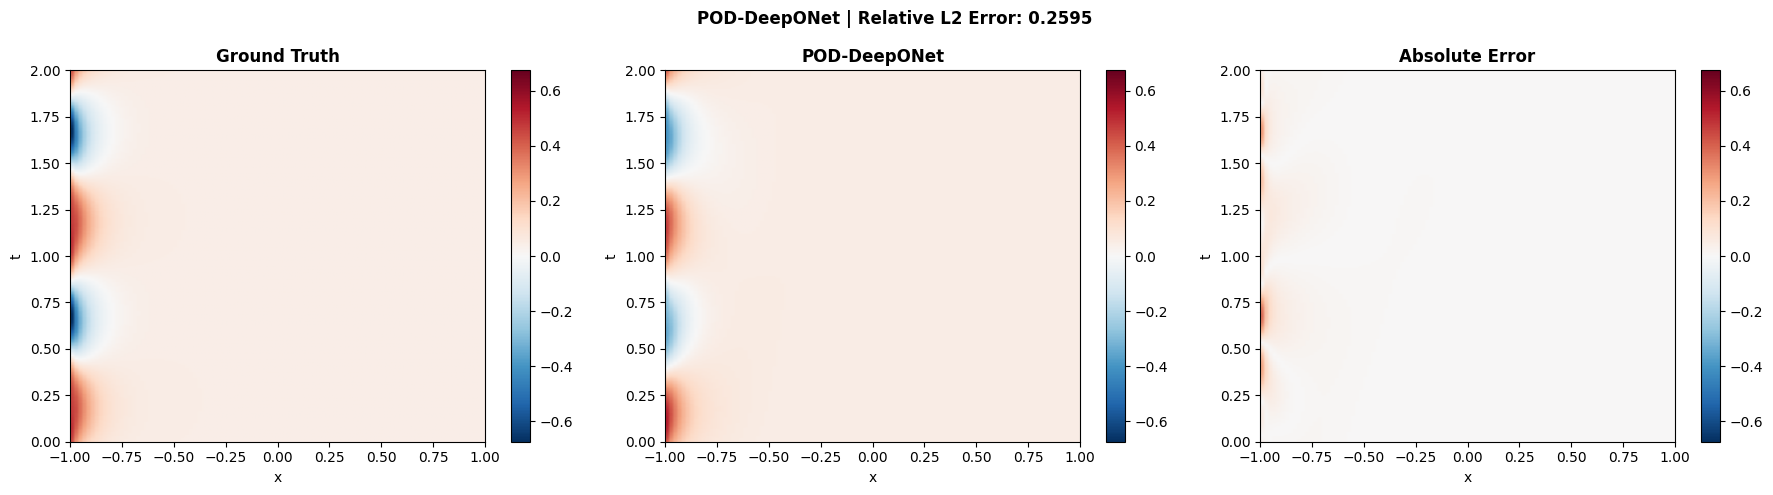

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, arr, title in zip(axes, [true_np, pred_np, err_np],
                           ["Ground Truth", "POD-DeepONet", "Absolute Error"]):
    im = ax.imshow(arr, aspect='auto', origin='lower', cmap='RdBu_r',
                   extent=[x_np.min(), x_np.max(), 0, 2], vmin=-vmax, vmax=vmax)
    ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)

rel_err = np.linalg.norm(true_np - pred_np) / np.linalg.norm(true_np)
fig.suptitle(f"POD-DeepONet | Relative L2 Error: {rel_err:.4f}", fontweight='bold')
plt.tight_layout()
plt.show()
